In [1]:
import torch.utils.data as data
import numpy as np
import os
import sys
from PIL import Image
import torch
import random
import math
from tqdm import tqdm
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import subprocess
from collections import defaultdict

from torch.autograd import Variable
from torchinfo import summary

print(torchvision.__version__)
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.current_device())

0.10.0+cu111
1.9.0+cu111
True
0


In [33]:
LABEL_TABLE = {"bite": 0, "drink": 1, "non_intake": 2}
gt_loc = "D:/eat_detection/all_labels/"
#result_loc = "D:/OneDrive/PhD/work/eat_detection/CafeteriaData/test_results/test_RES_LSTM_30_16_8_v4/"
#result_loc = "D:/eat_detection/results_1stage/test_RES_LSTM_30_16_8_v4/"
result_loc = "D:/eat_detection/results_2stage/result_single_lstm_30_16_8_v4_2stage_all/"
#result_loc = "D:/eat_detection/results_10runs/1/result_RES_LSTM_30_16_8_v4_test/"
pred_loc = result_loc + "frame_preds/"
def read_results(video_idx):
    min_num = 0
    preds = []
    labels = [] 
    results = open("{}preds_{}.txt".format(pred_loc,video_idx),"r")
    for line in results.readlines():
        image_name = line.split("\t")[0]
        preds.append(int(line.split("\t")[2].split("\n")[0]))
        labels.append(int(line.split("\t")[1].split("\n")[0]))

        if not min_num:
            min_num = int(image_name[6:12])
    return np.array(preds),np.array(labels), min_num

### smooth predictoin results

In [34]:
videolist = [f[6:-4] for f in os.listdir(pred_loc) if f.startswith("preds")]
#videolist = ["p086_c1"]

fps = 8
#downsample_rate = 4
downsample_rate = 1
def smooth_results(results,kernel1=1,kernel2=1,kernel3=1,kernel4=1):
    #results,kernel1=8,kernel2=4,kernel3=8,kernel4=8
    #results,kernel1=8,kernel2=4,kernel3=8,kernel4=16
    """
    kernel1: for filling small gaps between bite gestures
    kernel2: for filling small gaps between drink gestures
    kernel3: for removing short bite gestures
    kernel4: for removing short drink gestures
    """
    smoothed = np.copy(results)
    for i in range(kernel1,len(results)):
        if results[i-kernel1+1] == results[i] and results[i] == 0:
            smoothed[i-kernel1+2:i] = results[i-kernel1+1]
    results = smoothed
    for i in range(kernel2,len(results)):
        if results[i-kernel2+1] == results[i] and results[i] == 1:
            smoothed[i-kernel2+2:i] = results[i-kernel2+1]
    results = smoothed
    for i in range(kernel3,len(results)):
        if results[i-kernel3+1] == results[i] and \
            results[i] == 2 and \
            0 in results[i-kernel3+2:i] and \
            1 not in results[i-kernel4+2:i]:
            smoothed[i-kernel3+2:i] = 2
    results = smoothed
    for i in range(kernel4,len(results)):
        if results[i-kernel4+1] == results[i] and \
            results[i] == 2 and \
            1 in results[i-kernel4+2:i] and \
            0 not in results[i-kernel4+2:i]:
            smoothed[i-kernel4+2:i] = 2
    return smoothed

try:
    os.mkdir(f"{result_loc}ges_boundaries/")
except:
    pass
for video_idx in videolist:
    preds, labels, start_idx = read_results(video_idx)
    smoothed_preds = smooth_results(preds)
    #smoothed_preds = preds
    cur_start = -1
    pred_boundaries = []
    pred_types = []
    pre_pred = -1
    for idx, pred in enumerate(smoothed_preds):
        if pred == pre_pred:
            continue
        if cur_start == -1 and pred == 2:
            continue
        if idx != 0 and cur_start != -1:
            pred_types.append(pre_pred)
            pred_boundaries.append([cur_start+start_idx,(idx-1)*downsample_rate+start_idx])
            cur_start = -1
        else:
            cur_start = idx * downsample_rate
        pre_pred = pred
        
    f = open(f"{result_loc}ges_boundaries/ges_{video_idx}.txt","w")
    f.write("\n".join(["{}\t{}\t{}".\
            format(ges_type,boundary[0],boundary[1]) \
            for ges_type,boundary in (zip(pred_types,pred_boundaries))]))
    f.close()


### gesture-wise results evaluation

In [35]:
class AverageMeter(object):
    """Computes and stores the average and current value"""

    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

def evaluate_results(gt, pred, matrixs):
    #handle edge cases when gt or pred is empty
    if len(gt) == 0 and len(pred) == 0:
        return matrixs
    elif len(gt) == 0:
        matrixs[pred[0][0]]["fp"] += 1
        return evaluate_results(gt, pred[1:], matrixs)
    elif len(pred) == 0:
        matrixs[gt[0][0]]["missed"] += 1
        return evaluate_results(gt[1:], pred, matrixs)
    else:
        # read in first gesture in gt and pred, respectively
        gt_start = gt[0][1]
        gt_end = gt[0][2]
        gt_type = gt[0][0]
        pred_start = pred[0][1]
        pred_end = pred[0][2]
        pred_type = pred[0][0]
        overlap = min(pred_end-gt_start,gt_end-pred_start)  
        # the gt gesture and predicted gesture are considered matched when
        # the overlap is above 50% of either of them.
        if overlap < (gt_end-gt_start)*0.5 and \
                overlap < (pred_end-pred_start)*0.5:
            if pred_start < gt_start:
                matrixs[pred_type]["fp"] += 1
                return evaluate_results(gt, pred[1:], matrixs)
            else:
                matrixs[gt_type]["missed"] += 1
                return evaluate_results(gt[1:], pred, matrixs)  
        else:
            if gt_type == pred_type:
                matrixs[gt_type]["tp"] += 1
            else:
                matrixs[gt_type]["confused"] += 1
            return evaluate_results(gt[1:], pred[1:], matrixs)

    

In [36]:
pred_ges_loc = result_loc + "ges_boundaries/"

video_list = [f[4:-4] for f in os.listdir(pred_ges_loc) if f.startswith("ges")]
subject_list = np.array([str.split(video,"_")[0] for video in video_list])
subject_set = sorted(np.unique(subject_list),reverse=False)
matrixs = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: 0)))

for video_idx in video_list:
    subject = video_idx
    subject = str.split(video_idx,"_")[0]
    f_gt = open(f"{gt_loc}{video_idx}/gt_ges_3labels.txt","r")
    gt = []
    bite_average = AverageMeter()
    drink_average = AverageMeter()

    for line in f_gt.readlines():
        info = str.split(str.split(line, "\n")[0], "\t") 
        gt.append([LABEL_TABLE[info[0]],int(info[1]),int(info[2])])
        if info[0] == "bite":
            bite_average.update(int(info[2])-int(info[1]))
        if info[0] == "drink":
            drink_average.update(int(info[2])-int(info[1]))
    matrixs[subject][0]["average_len"] = bite_average.avg
    matrixs[subject][1]["average_len"] = drink_average.avg

    f_gt.close()
    f_pred = open(f"{pred_ges_loc}ges_{video_idx}.txt","r")
    pred = []
    for line in f_pred.readlines():
        info = str.split(str.split(line, "\n")[0], "\t") 
        pred.append([int(info[0]),int(info[1]),int(info[2])])
    f_pred.close()
    evaluate_results(gt, pred, matrixs[subject])
    
summary_matrixs = defaultdict(lambda: defaultdict(lambda: 0))
for ges_type in range(2):
    for key in ['tp','fp','missed','confused']:
        #for subject in video_list:
        for subject in subject_set:
            #if subject in bad_video_list:
            #    continue
            summary_matrixs[ges_type][key] += matrixs[subject][ges_type][key]

gt_loc = pred_loc
pred_ges_loc = result_loc + "ges_boundaries/"
video_list = [f[4:-4] for f in os.listdir(pred_ges_loc) if f.startswith("ges")]
subject_list = np.array([str.split(video,"_")[0] for video in video_list])
subject_set = sorted(np.unique(subject_list),reverse=False)
matrixs = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: 0)))

for video_idx in video_list:
    subject = video_idx
    #subject = str.split(video_idx,"_")[0]
    f_gt = open(f"{gt_loc}{video_idx}/gt_ges_3labels.txt","r")
    gt = []
    bite_average = AverageMeter()
    drink_average = AverageMeter()

    for line in f_gt.readlines():
        info = str.split(str.split(line, "\n")[0], "\t") 
        gt.append([LABEL_TABLE[info[0]],int(info[1]),int(info[2])])
        if info[0] == "bite":
            bite_average.update(int(info[2])-int(info[1]))
        if info[0] == "drink":
            drink_average.update(int(info[2])-int(info[1]))
    matrixs[subject][0]["average_len"] = bite_average.avg
    matrixs[subject][1]["average_len"] = drink_average.avg

    f_gt.close()
    f_pred = open(f"{pred_ges_loc}ges_{video_idx}.txt","r")
    pred = []
    for line in f_pred.readlines():
        info = str.split(str.split(line, "\n")[0], "\t") 
        pred.append([int(info[0]),int(info[1]),int(info[2])])
    f_pred.close()
    evaluate_results(gt, pred, matrixs[subject])
    
summary_matrixs = defaultdict(lambda: defaultdict(lambda: 0))
for ges_type in range(2):
    for key in ['tp','fp','missed','confused']:
        for subject in video_list:
            #if subject in bad_video_list:
            #    continue
            summary_matrixs[ges_type][key] += matrixs[subject][ges_type][key]

In [32]:
print(f"\t\tbite\tdrink\t")
print(f"=====summary=======================")
print(f"TP\t\t{summary_matrixs[0]['tp']}\t{summary_matrixs[1]['tp']}")
print(f"FP\t\t{summary_matrixs[0]['fp']}\t{summary_matrixs[1]['fp']}")
print(f"Missed\t\t{summary_matrixs[0]['missed']}\t{summary_matrixs[1]['missed']}")
print(f"Confused\t{summary_matrixs[0]['confused']}\t{summary_matrixs[1]['confused']}")
print(f"Precision\t"
        f"{summary_matrixs[0]['tp']/(summary_matrixs[0]['tp']+summary_matrixs[0]['fp']):.2f}\t"
        f"{summary_matrixs[1]['tp']/(summary_matrixs[1]['tp']+summary_matrixs[1]['fp']):.2f}")
print(f"Recall\t\t"
      f"{summary_matrixs[0]['tp']/(summary_matrixs[0]['tp']+summary_matrixs[0]['missed']):.2f}\t"
        f"{summary_matrixs[1]['tp']/(summary_matrixs[1]['tp']+summary_matrixs[1]['missed']):.2f}")
print(f"F1 score\t"
      f"{summary_matrixs[0]['tp']/(summary_matrixs[0]['tp']+0.5*(summary_matrixs[0]['fp']+summary_matrixs[0]['missed'])):.2f}\t"
        f"{summary_matrixs[1]['tp']/(summary_matrixs[1]['tp']+0.5*(summary_matrixs[1]['fp']+summary_matrixs[1]['missed'])):.2f}")

		bite	drink	
=====summary=======================
TP		453	12
FP		2685	652
Missed		2485	474
Confused	87	66
Precision	0.14	0.02
Recall		0.15	0.02
F1 score	0.15	0.02


In [66]:
average_precision = defaultdict(lambda: 0)
average_recall = defaultdict(lambda: 0)
bite_precision = defaultdict(lambda: 0) 
bite_recall = defaultdict(lambda: 0) 

#for subject in video_list:
for subject in subject_set:

    try:
        matrixs[subject][0]['precision'] = matrixs[subject][0]['tp']/(matrixs[subject][0]['tp']+matrixs[subject][0]['fp'])
    except:
        pass
    try:
        matrixs[subject][1]['precision'] = matrixs[subject][1]['tp']/(matrixs[subject][1]['tp']+matrixs[subject][1]['fp'])
    except:
        pass
    bite_precision[subject] = matrixs[subject][0]['precision']   
    # if there is a precision in "drink"
    if matrixs[subject][1]['tp']+matrixs[subject][1]['fp'] != 0:
        #average_precision[subject] = matrixs[subject][0]['precision']
        average_precision[subject] = (matrixs[subject][0]['precision'] + matrixs[subject][1]['precision']) / 2
    else:
        average_precision[subject] = matrixs[subject][0]['precision']
    
    try:
        matrixs[subject][0]['recall'] = matrixs[subject][0]['tp']/(matrixs[subject][0]['tp']+matrixs[subject][0]['missed'])
    except:
        pass
    try:
        matrixs[subject][1]['recall'] = matrixs[subject][1]['tp']/(matrixs[subject][1]['tp']+matrixs[subject][1]['missed'])
    except:
        pass
    try:
        matrixs[subject][0]['f1'] = matrixs[subject][0]['tp']/(matrixs[subject][0]['tp']+0.5*(matrixs[subject][0]['fp']+matrixs[subject][0]['missed']))
    except:
        pass
    try:
        matrixs[subject][1]['f1'] = matrixs[subject][1]['tp']/(matrixs[subject][1]['tp']+0.5*(matrixs[subject][1]['fp']+matrixs[subject][1]['missed']))
    except:
        pass
    bite_recall[subject] = matrixs[subject][0]['recall']   
    # if there is a recall in "drink"
    if matrixs[subject][1]['tp']+matrixs[subject][1]['missed'] != 0:
        average_recall[subject] = (matrixs[subject][0]['recall'] + matrixs[subject][1]['recall']) / 2
    else:
        average_recall[subject] = matrixs[subject][0]['recall']


In [67]:
sorted_average_precision = {k: v for k, v in sorted(average_precision.items(), key=lambda item: item[1])}
sorted_average_recall = {k: v for k, v in sorted(average_recall.items(), key=lambda item: item[1])}

sorted_bite_precision = {k: v for k, v in sorted(bite_precision.items(), key=lambda item: item[1])}
sorted_bite_recall = {k: v for k, v in sorted(bite_recall.items(), key=lambda item: item[1])}

In [68]:
print(f"\t\tbite\tdrink\t")
print(f"=====summary=======================")
print(f"TP\t\t{summary_matrixs[0]['tp']}\t{summary_matrixs[1]['tp']}")
print(f"FP\t\t{summary_matrixs[0]['fp']}\t{summary_matrixs[1]['fp']}")
print(f"Missed\t\t{summary_matrixs[0]['missed']}\t{summary_matrixs[1]['missed']}")
print(f"Confused\t{summary_matrixs[0]['confused']}\t{summary_matrixs[1]['confused']}")
print(f"Precision\t"
        f"{summary_matrixs[0]['tp']/(summary_matrixs[0]['tp']+summary_matrixs[0]['fp']):.2f}\t"
        f"{summary_matrixs[1]['tp']/(summary_matrixs[1]['tp']+summary_matrixs[1]['fp']):.2f}")
print(f"Recall\t\t"
      f"{summary_matrixs[0]['tp']/(summary_matrixs[0]['tp']+summary_matrixs[0]['missed']):.2f}\t"
        f"{summary_matrixs[1]['tp']/(summary_matrixs[1]['tp']+summary_matrixs[1]['missed']):.2f}")

pivot = 10
print(f"=====lowest {pivot} average precision=====")
count = 0
bad_video_list = []
for k, v in sorted_bite_precision.items():
    print(f"{k}: {v:.2f}")
    bad_video_list.append(k)
    count += 1
    if count >= pivot:
        break
print(f"=====lowest {pivot} average recall========")
count = 0
for k, v in sorted_bite_recall.items():
    print(f"{k}: {v:.2f}")
    bad_video_list.append(k)
    count += 1
    if count >= pivot:
        break
bad_video_list = sorted(list(set(bad_video_list)))

		bite	drink	
=====summary=======================
TP		2453	430
FP		647	97
Missed		544	120
Confused	28	2
Precision	0.79	0.82
Recall		0.82	0.78
=====lowest 10 average precision=====
p096: 0.50
p145: 0.58
p324: 0.60
p016: 0.63
p279: 0.67
p069: 0.69
p159: 0.70
p190: 0.72
p291: 0.72
p293: 0.74
=====lowest 10 average recall========
p148: 0.56
p139: 0.57
p072: 0.59
p293: 0.60
p037: 0.63
p270: 0.64
p192: 0.69
p265: 0.69
p015: 0.70
p190: 0.75


In [69]:
len(bad_video_list)

18

In [70]:
for subject in bad_video_list:
    print(f"====={subject}=========================")
    print(f"TP\t\t{matrixs[subject][0]['tp']}\t{matrixs[subject][1]['tp']}")
    print(f"FP\t\t{matrixs[subject][0]['fp']}\t{matrixs[subject][1]['fp']}")
    print(f"Missed\t\t{matrixs[subject][0]['missed']}\t{matrixs[subject][1]['missed']}")
    print(f"Confused\t{matrixs[subject][0]['confused']}\t{matrixs[subject][1]['confused']}")
    print(f"Precision\t"
          f"{matrixs[subject][0]['precision']:.2f}\t"
          f"{matrixs[subject][1]['precision']:.2f}")
    print(f"Recall\t\t"
          f"{matrixs[subject][0]['recall']:.2f}\t"
        f"{matrixs[subject][1]['recall']:.2f}")
    print(f"average len\t"
          f"{matrixs[subject][0]['average_len']:.2f}\t"
        f"{matrixs[subject][1]['average_len']:.2f}")

=====p015=========================
TP		32	7
FP		2	1
Missed		14	1
Confused	0	0
Precision	0.94	0.88
Recall		0.70	0.88
average len	21.04	34.75
=====p016=========================
TP		43	9
FP		25	1
Missed		4	1
Confused	1	0
Precision	0.63	0.90
Recall		0.91	0.90
average len	16.50	42.00
=====p037=========================
TP		64	4
FP		16	0
Missed		37	1
Confused	0	0
Precision	0.80	1.00
Recall		0.63	0.80
average len	13.26	26.00
=====p069=========================
TP		64	6
FP		29	0
Missed		15	2
Confused	0	0
Precision	0.69	1.00
Recall		0.81	0.75
average len	15.19	45.17
=====p072=========================
TP		40	13
FP		7	2
Missed		28	1
Confused	0	0
Precision	0.85	0.87
Recall		0.59	0.93
average len	17.29	40.14
=====p096=========================
TP		46	2
FP		46	0
Missed		1	3
Confused	0	0
Precision	0.50	1.00
Recall		0.98	0.40
average len	18.74	57.00
=====p139=========================
TP		13	10
FP		1	22
Missed		10	0
Confused	0	0
Precision	0.93	0.31
Recall		0.57	1.00
average len	18.78	47.60
=====p145======

# comment v2 07/12/2021
bad precision:
p069_c3 (0.52), p069_c1 (0.59):
some MD gestures do not have enough overlap with GT gestures.

recall
p270_c4 (0.37), p270_c5 (0.38):
Those missed bite gestures tend to be quick and close to other gestures.
In p270_c5, all bites when eating an apple and cookies are missed. 

p148_c2: 0.48
misses most bites when eating fries.
p293_c2: 0.48

p192_c1: 0.59
misses some bites when eating black food

In [71]:
idx = 1395
offset = 778
(idx/15*1000+offset)/1000*8

750.224

# comment v1 07/01/2021
p016_c2: subject behaves some fake bite gestures, have food on forks, bring to the mouth but do not eat it; GT drink are not labeled correctly

p059_c1: some close MD drink gestures are concatenated, and completely missed some drink gestures.

p060_c2: completely fail

p190_c1: completely fail

p265_c2: drink detection are bad.

p270_c4: not detecting many bites at all

p279_c1: many utensilings are detected as bites

p279_c3: miss some bites. some wrongly detected drinks. most detected events are short.

p291_c2: subject's wiping the mouth is detected as bites. miss all drinks.

p293_c2: many utensilings (especially when holding a fork) are detected as bites

p324_c2: miss all drinks using non-dominant hands

p037_c2, p069_c1, p166_c2, p219_c1: drink gestures are too few


### Result matrixs

In [75]:
bite_len = []
drink_len = []
bite_precision = []
drink_precision = []
bite_recall = []
drink_recall = []
bite_f1 = []
drink_f1 = []
#for subject in video_list:
for subject in subject_set:
    if matrixs[subject][0]['tp']+matrixs[subject][0]['missed'] != 0:
        bite_len.append(matrixs[subject][0]['average_len'])
        bite_precision.append(matrixs[subject][0]['precision'])
        bite_recall.append(matrixs[subject][0]['recall'])
        bite_f1.append(matrixs[subject][0]['f1'])
    if matrixs[subject][1]['tp']+matrixs[subject][1]['missed'] != 0:   
        drink_len.append(matrixs[subject][1]['average_len'])
        drink_precision.append(matrixs[subject][1]['precision'])
        drink_recall.append(matrixs[subject][1]['recall'])
        drink_f1.append(matrixs[subject][1]['f1'])        



In [105]:
print(f"bite_recall:\tmean: {np.mean(bite_recall)}\t\tstd: {np.std(bite_recall)}")
print(f"drink_recall:\tmean: {np.mean(drink_recall)}\tstd: {np.std(drink_recall)}")
print(f"bite_prec:\tmean: {np.mean(bite_precision)}\tstd: {np.std(bite_precision)}")
print(f"drink_prec:\tmean: {np.mean(drink_precision)}\tstd: {np.std(drink_precision)}")
print(f"bite_f1:\tmean: {np.mean(bite_f1)}\tstd: {np.std(bite_f1)}")
print(f"drink_f1:\tmean: {np.mean(drink_f1)}\tstd: {np.std(drink_f1)}")



bite_recall:	mean: 0.834676360473231		std: 0.1304339049574256
drink_recall:	mean: 0.7916533716661402	std: 0.16972515111848754
bite_prec:	mean: 0.8125375462534716	std: 0.11587927158027699
drink_prec:	mean: 0.8698821690609785	std: 0.1736271194764706
bite_f1:	mean: 0.8134610896300319	std: 0.09515100473487492
drink_f1:	mean: 0.8012563422647961	std: 0.15354723367163797


In [112]:
len(drink_recall)

40

### Result plots

In [77]:
import matplotlib.pyplot as plt
import matplotlib
font = {'weight' : 'normal','size': 18}

matplotlib.rc('font', **font)

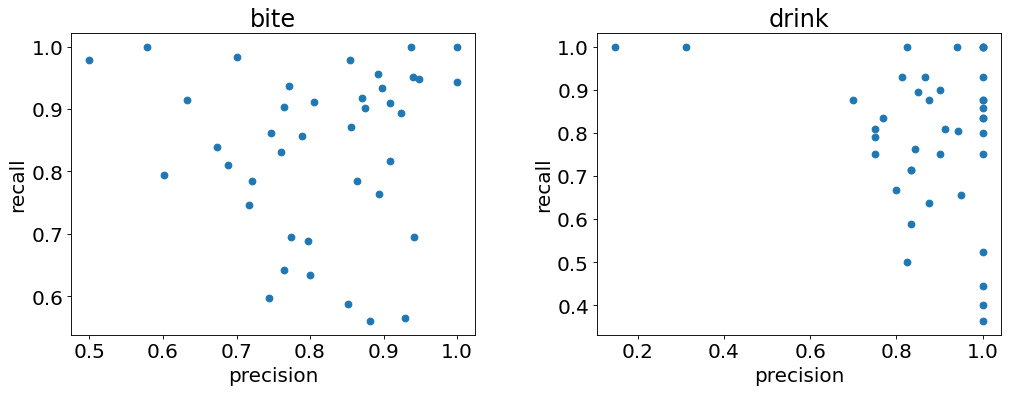

In [109]:
plt.figure(figsize=(15, 5), dpi=80)
plt.subplot(1,2,1)
plt.title("bite",fontsize='large',fontweight='medium')
plt.scatter(bite_precision, bite_recall)
plt.xlabel("precision")
plt.ylabel("recall")

plt.subplot(1,2,2)
plt.title("drink",fontsize='large',fontweight='medium')
plt.scatter(drink_precision, drink_recall)
plt.xlabel("precision")
plt.ylabel("recall")
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=None)
plt.show()

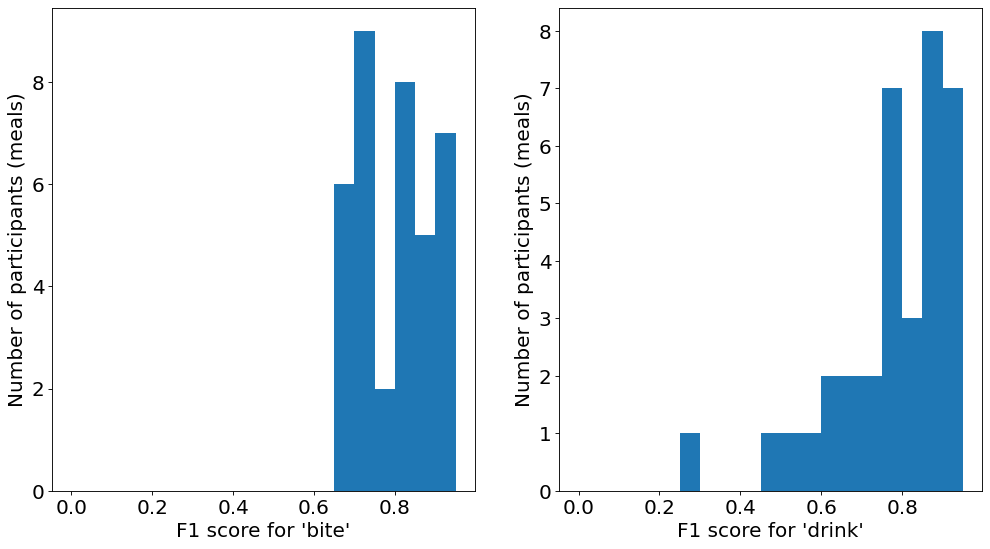

In [106]:
plt.figure(figsize=(15, 8), dpi=80)
plt.subplot(1,2,1)
plt.hist(bite_f1,
         bins=np.arange(0.0,1.0,0.05),
         histtype='bar')
plt.xlabel("F1 score for 'bite'")
plt.ylabel("Number of participants (meals)")

plt.subplot(1,2,2)
plt.hist(drink_f1,
         bins=np.arange(0.0,1.0,0.05),
         histtype='bar')
plt.xlabel("F1 score for 'drink'")
plt.ylabel("Number of participants (meals)")

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.4)
plt.show()

In [7]:
a = [1,2,2,3]
a.index(2)

1

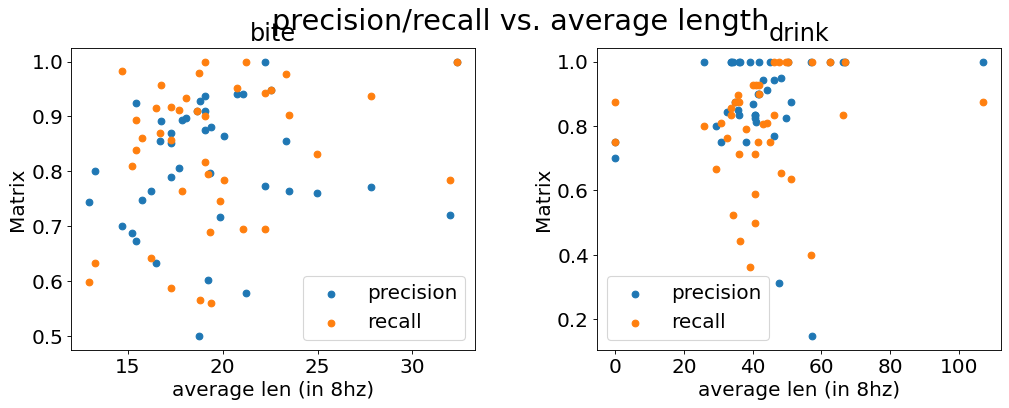

In [80]:
plt.figure(figsize=(15, 5), dpi=80)
plt.suptitle("precision/recall vs. average length",fontsize='x-large',fontweight='medium')
plt.subplot(1,2,1)
plt.title("bite",fontsize='large',fontweight='medium')
plt.scatter(bite_len, bite_precision)
plt.scatter(bite_len, bite_recall)
plt.xlabel("average len (in 8hz)")
plt.ylabel("Matrix")
plt.legend(["precision","recall"])

plt.subplot(1,2,2)
plt.title("drink",fontsize='large',fontweight='medium')
plt.scatter(drink_len, drink_precision)
plt.scatter(drink_len, drink_recall)
plt.xlabel("average len (in 8hz)")
plt.ylabel("Matrix")
plt.legend(["precision","recall"])

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=None)
plt.show()

### Frame-wise result evaluation

In [17]:
pred_frame_loc = result_loc + "frame_preds/"
video_list = [f[6:-4] for f in os.listdir(pred_frame_loc) if f.startswith("preds")]
frame_matrix = [defaultdict(lambda: defaultdict(lambda: 0)) for _ in range(3)]

total_tp = np.array([0,0,0])
total_p = np.array([0,0,0])
total_detect = np.array([0,0,0])
subject_list = np.array([str.split(video,"_")[0] for video in video_list])
subject_set = sorted(np.unique(subject_list),reverse=False)
#bad_subjects = ['p139','p285','p361']
bad_subjects = []
for video_idx in video_list:
    subject = str.split(video_idx,"_")[0]
    frame_gt = []
    f_pred = open(f"{pred_frame_loc}preds_{video_idx}.txt","r")
    frame_preds = []
    for line in f_pred.readlines():
        info = str.split(str.split(line, "\n")[0], "\t") 
        frame_gt.append(int(info[1]))
        frame_preds.append(int(info[2]))
    frame_preds = np.array(frame_preds)
    frame_gt = np.array(frame_gt)
    f_pred.close()
    cur_uar = 0

    for label in range(3):
        cur_tp = np.logical_and(frame_preds == frame_gt, frame_gt==label).sum()
        cur_p = (frame_gt == label).sum().item()
        cur_detect = (frame_preds == label).sum().item()
        frame_matrix[label][subject]["tp"] += cur_tp
        frame_matrix[label][subject]["p"] += cur_p
        frame_matrix[label][subject]["detect"] += cur_detect
        total_tp[label] += cur_tp
        total_p[label] += cur_p
        total_detect[label] += cur_detect

In [20]:
recall = total_tp/total_p
precision = total_tp/total_detect
f1 = 2 * (recall*precision) / (recall+precision)
frame_uar = np.mean(total_tp/total_p)

print(f"for all frames")
print(f"average uar: {frame_uar}")
print(f"tp: {total_tp}")
print(f"p: {total_p}")
print(f"detection: {total_detect}")
print(f"precision: {precision}")
print(f"recall: {recall}")
print(f"f1 {f1}")

for all frames
average uar: 0.8121212194304416
tp: [ 36430  21779 321511]
p: [ 56508  24876 350928]
detection: [ 56600  31595 344117]
precision: [0.64363958 0.68931793 0.93430723]
recall: [0.64468748 0.87550249 0.91617369]
f1 [0.6441631  0.77133396 0.92515161]


In [57]:
uar_dict = defaultdict(lambda: 0) 
recall_dict = [defaultdict(lambda: 0) for _ in range(3)]
precision_dict = [defaultdict(lambda: 0) for _ in range(3)]
f1_dict = [defaultdict(lambda: 0) for _ in range(3)]
for subject in subject_set:
    for label in range(3):
        recall_dict[label][subject] = frame_matrix[label][subject]["tp"] / frame_matrix[label][subject]["p"]
        precision_dict[label][subject] = frame_matrix[label][subject]["tp"] / frame_matrix[label][subject]["detect"]
        f1_dict[label][subject] = 2 * (recall_dict[label][subject]*precision_dict[label][subject]) / (recall_dict[label][subject]+precision_dict[label][subject])
        uar_dict[subject] += recall_dict[label][subject]
    uar_dict[subject] = uar_dict[subject]/3    
    
recall_list = []
precision_list = []
f1_list = []
uar_list = list(uar_dict.values())
for label in range(3):
    recall_list.append(list(recall_dict[label].values()))
    precision_list.append(list(precision_dict[label].values()))
    f1_list.append(list(f1_dict[label].values()))

In [59]:
print(f"uar: mean: {np.mean(uar_list)}; std: {np.std(uar_list)}")

uar: mean: 0.8120667934254321; std: 0.05222157203610562


In [54]:
print(f"for participants")
print(f"recall for bite: mean: {np.mean(recall_list[0])}; std: {np.std(recall_list[0])}")
print(f"recall for drink: mean: {np.mean(recall_list[1])}; std: {np.std(recall_list[1])}")
print(f"recall for non-intake: mean: {np.mean(recall_list[2])}; std: {np.std(recall_list[2])}")
print("------------------------------------------------------------")
print(f"precision for bite: mean: {np.mean(precision_list[0])}; std: {np.std(precision_list[0])}")
print(f"precision for drink: mean: {np.mean(precision_list[1])}; std: {np.std(precision_list[1])}")
print(f"precision for non-intake: mean: {np.mean(precision_list[2])}; std: {np.std(precision_list[2])}")
print("------------------------------------------------------------")
print(f"f1 for bite: mean: {np.mean(f1_list[0])}; std: {np.std(f1_list[0])}")
print(f"f1 for drink: mean: {np.mean(f1_list[1])}; std: {np.std(f1_list[1])}")
print(f"f1 for non-intake: mean: {np.mean(f1_list[2])}; std: {np.std(f1_list[2])}")


for participants
recall for bite: mean: 0.6517256544030687; std: 0.12765630732780464
recall for drink: mean: 0.8692000454393204; std: 0.09016816242604321
recall for non-intake: mean: 0.9152746804339073; std: 0.05285680338252555
------------------------------------------------------------
precision for bite: mean: 0.6957560583364025; std: 0.1557008473022539
precision for drink: mean: 0.70500832099051; std: 0.17861026950221467
precision for non-intake: mean: 0.9322267013355503; std: 0.03218550825745765
------------------------------------------------------------
f1 for bite: mean: 0.6484365172376624; std: 0.073171626550479
f1 for drink: mean: 0.766571719232751; std: 0.14693386253383228
f1 for non-intake: mean: 0.922667662508028; std: 0.03286377776620898


### Count the difference between orginal and augmented gt

In [ ]:
gt_loc = "/scratch1/zeyut/eat_detection/all_labels/"
video_list = [f for f in os.listdir(gt_loc)]
bite_count = 0
drink_count = 0

for video_idx in video_list:
    subject = video_idx
    #subject = str.split(video_idx,"_")[0]
    f_gt = open(f"{gt_loc}{video_idx}/gt_ges_3labels.txt","r")
    for line in f_gt.readlines():
        info = str.split(str.split(line, "\n")[0], "\t") 
        if info[0] == "bite":
            bite_count += 1
        if info[0] == "drink":
            drink_count += 1 
print(f"drink: {drink_count}")
print(f"bite: {bite_count}")

### Gesture count results

In [304]:
video_idx = 625
offset = 910
(video_idx/8*1000-offset)/1000*15

1158.2250000000001

In [31]:
620 * 1000 / 8

77500.0

In [32]:
(77500.0 - 7312 ) * 15 /1000

1052.82

In [305]:
sensor_idx = 841
(sensor_idx/15*1000+offset)/1000*8

455.8133333333334

bad videos on 'bite':
p086,p324

bad videos on 'drink':
p059,p139,p190,p265,p285,p292

bad videos on 'uar':
p139,p285,p361,p015,p086,p279,p291,p270,p060,p217